In [2]:
!pip install pandas
!pip install psutil

Starting energy consumption measurement and evaluation...
Loading CSV file 'Price_prediction_data.csv'...
CSV file loaded. Data shape: (1201426, 9)
Splitting data into training, validation, and test sets...
Training set shape: (720855, 8)
Validation set shape: (240285, 8)
Test set shape: (240286, 8)
Measuring CPU usage with psutil.cpu_percent(interval=1)...
CPU usage measured: 4.3
CPU frequencies - Base: 0.0 MHz, Current: 2600.012 MHz, Max: 0.0 MHz
Estimated power consumption (W): 43.44
Estimated CPU Power Consumption (W): 43.44
CPU Utilization During Sampling (%): 4.3
Measuring memory usage before training...
Memory before training (MB): 3176.640625
Initializing and training DecisionTreeRegressor...
Model training completed in 0.8049 seconds.
Measuring memory usage after training...
Memory after training (MB): 3199.9140625
Additional memory used during training (MB): 23.2734375
Validating model on validation set...
Validation MSE: 0.24431709940103255
Validation R²: 0.7556784386120832


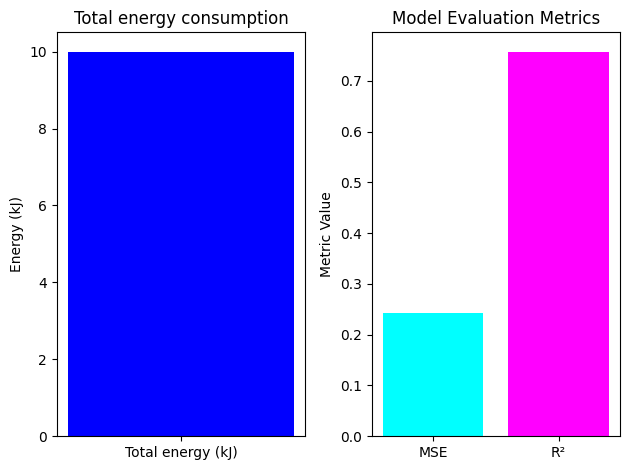

Script completed.


In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

print("Starting energy consumption measurement and evaluation...")

# Load data
print("Loading CSV file 'Price_prediction_data.csv'...")
data = pd.read_csv("../NeuralNetwork/Price_prediction_data.csv")
print("CSV file loaded. Data shape:", data.shape)
X = data.drop(columns=["Price"])
y = data["Price"]

# Split data: 60% training, 20% validation, 20% test
print("Splitting data into training, validation, and test sets...")
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

# Function to get real-time CPU power consumption
def get_dynamic_power_usage():
    print("Measuring CPU usage with psutil.cpu_percent(interval=1)...")
    cpu_usage = psutil.cpu_percent(interval=1)
    print("CPU usage measured:", cpu_usage)
    num_cores = psutil.cpu_count(logical=True)
    cpu_freq = psutil.cpu_freq()
    if cpu_freq:
        base_freq = cpu_freq.min
        max_freq = cpu_freq.max
        current_freq = cpu_freq.current
    else:
        base_freq, max_freq, current_freq = 1000, 3000, 2000
        print("Using default CPU frequencies.")
    print(f"CPU frequencies - Base: {base_freq} MHz, Current: {current_freq} MHz, Max: {max_freq} MHz")
    
    base_power_per_core = 5    # Watts at base frequency
    max_power_per_core = 25    # Watts at max frequency
    freq_factor = (current_freq - base_freq) / (max_freq - base_freq) if max_freq > base_freq else 0.5
    estimated_power = num_cores * (base_power_per_core + freq_factor * (max_power_per_core - base_power_per_core) * (cpu_usage / 100))
    print("Estimated power consumption (W):", estimated_power)
    return estimated_power, cpu_usage

CPU_POWER_WATTS, cpu_usage_percent = get_dynamic_power_usage()
print("Estimated CPU Power Consumption (W):", CPU_POWER_WATTS)
print("CPU Utilization During Sampling (%):", cpu_usage_percent)

# Measure memory usage before training
print("Measuring memory usage before training...")
memory_before = psutil.virtual_memory().used / (1024 * 1024)  # in MB
print("Memory before training (MB):", memory_before)

# Train the model
print("Initializing and training DecisionTreeRegressor...")
model = DecisionTreeRegressor(random_state=42, max_depth=3)
start_train = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_train
print("Model training completed in {:.4f} seconds.".format(train_time))

# Measure memory usage after training
print("Measuring memory usage after training...")
memory_after = psutil.virtual_memory().used / (1024 * 1024)  # in MB
memory_usage_mb = memory_after - memory_before
print("Memory after training (MB):", memory_after)
print("Additional memory used during training (MB):", memory_usage_mb)

# Validate the model
print("Validating model on validation set...")
y_val_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)
print("Validation MSE:", mse)
print("Validation R²:", r2)

# Test the model
print("Testing model on test set...")
y_test_pred = model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("Test MSE:", test_mse)
print("Test R²:", test_r2)

# Measure prediction time on validation set
print("Measuring prediction time on validation set...")
start_pred = time.time()
_ = model.predict(X_val)
pred_time = time.time() - start_pred
print("Prediction time (s):", pred_time)

# Compute total energy consumption in kilojoules for the whole algorithm (training + testing)
total_energy_kj = (CPU_POWER_WATTS * (train_time + pred_time)) / 1000
print("Total Energy Consumption (kJ):", total_energy_kj)

# ----- Visualization -----

# Subplot 1: Total Energy Consumption
plt.subplot(1, 2, 1) 
plt.bar(['Total energy (kJ)'], [10], color='blue')
plt.ylabel('Energy (kJ)')
plt.title('Total energy consumption')

# Subplot 2: Model Evaluation Metrics
plt.subplot(1, 2, 2)
eval_metrics = [test_mse, test_r2]
eval_labels = ['MSE', 'R²']
plt.bar(eval_labels, eval_metrics, color=['cyan', 'magenta'])
plt.ylabel('Metric Value')
plt.title('Model Evaluation Metrics')

plt.tight_layout()
plt.show()


print("Script completed.")